# Benchmark Demo — MLflow Run History & LLM-as-Judge
 前置：benchmark-service dev stack 已啟動（host port 8023），MLflow v3.14
 已帶著兩個安全中介層環境變數啟動（見 docs/Benchmark_Demo_Guide.md §0）。
 從 host 執行；需要 `pip install requests`（畫圖另需 matplotlib）。


In [1]:
import time
import subprocess
import requests

BASE = "http://localhost:8023/api/v1"      # benchmark-service（host 發布埠）
MLFLOW = "http://localhost:5557"           # v3.14 MLflow UI / REST（host 發布埠）
JUDGE_MODEL = "gemma3-12b"                  # 評審模型（走 BM_INFERENCE_URL=aiml-test-api:9997）
MLFLOW_CONTAINER = "aiml-v314-mlflow"       # Demo 2 會 stop/start 它

# 受測模型：註冊在 aiml-v314 registry 的 qwen3-0.6B（transformers 推理）。
# benchmark 透過 target_pipeline=lifecycle_infer 打 BM_LIFECYCLE_INFER_URL
# (=aiml-v314-api:9998)。config_override 決定用哪個模型/引擎，所以同一份
# schema 可以換模型重測。註：transformers 引擎的 temperature 必須 > 0。
TARGET_PIPELINE = "lifecycle_infer"
TARGET_CONFIG = {"model_name": "qwen3-0.6B", "engine": "transformers", "temperature": 0.7}


def create_schema(schema: dict) -> str:
    r = requests.post(f"{BASE}/benchmark/schemas", json=schema, timeout=30)
    r.raise_for_status()
    sid = r.json()["id"]
    print(f"schema created: {schema['name']} -> {sid}")
    return sid


def submit_run(schema_id: str, config_override: dict | None = None) -> str:
    body = {"schema_id": schema_id}
    if config_override is not None:
        body["config_override"] = config_override
    r = requests.post(f"{BASE}/benchmark/runs", json=body, timeout=30)
    r.raise_for_status()
    return r.json()["run_id"]


def wait_for_run(run_id: str, timeout: int = 300, interval: int = 3) -> dict:
    """Poll a run until completed/failed; return the final record."""
    deadline = time.time() + timeout
    while time.time() < deadline:
        rec = requests.get(f"{BASE}/benchmark/runs/{run_id}", timeout=30).json()
        if rec.get("status") in ("completed", "failed"):
            print(f"  run {run_id[:8]} -> {rec['status']} "
                  f"(aggregate={rec.get('aggregate_score')}, "
                  f"mlflow_run_id={rec.get('mlflow_run_id')})")
            return rec
        time.sleep(interval)
    raise TimeoutError(f"run {run_id} did not finish within {timeout}s")


def run_once(schema_id: str, config_override: dict | None = None) -> dict:
    """submit + wait，回傳完成後的 run 記錄。"""
    return wait_for_run(submit_run(schema_id, config_override))


def list_runs(schema_id: str) -> list:
    return requests.get(f"{BASE}/benchmark/schemas/{schema_id}/runs", timeout=30).json()


def compare(run_a: str, run_b: str, pairwise: bool = True) -> dict:
    r = requests.get(f"{BASE}/benchmark/runs/{run_a}/compare/{run_b}",
                     params={"pairwise": str(pairwise).lower()}, timeout=120)
    r.raise_for_status()
    return r.json()


# ── MLflow REST helpers（證明分數真的落到 tracking server）──────────
def mlflow_experiment_id(name: str) -> str | None:
    r = requests.get(f"{MLFLOW}/api/2.0/mlflow/experiments/get-by-name",
                     params={"experiment_name": name}, timeout=30)
    if r.status_code == 404:
        return None
    r.raise_for_status()
    return r.json()["experiment"]["experiment_id"]


def mlflow_runs(experiment_name: str) -> list:
    """回傳 [{run_name, metrics{...}}]，依開始時間排序（= 迭代順序）。"""
    exp_id = mlflow_experiment_id(experiment_name)
    if exp_id is None:
        return []
    r = requests.post(f"{MLFLOW}/api/2.0/mlflow/runs/search",
                      json={"experiment_ids": [exp_id],
                            "order_by": ["attributes.start_time ASC"],
                            "max_results": 1000}, timeout=30)
    r.raise_for_status()
    out = []
    for run in r.json().get("runs", []):
        metrics = {m["key"]: m["value"] for m in run["data"].get("metrics", [])}
        out.append({"run_name": run["info"]["run_name"], "metrics": metrics})
    return out


def docker(*args: str) -> None:
    p = subprocess.run(["docker", *args], capture_output=True, text=True)
    print((p.stdout + p.stderr).strip())


print("health:", requests.get("http://localhost:8023/health", timeout=10).json())


health: {'status': 'ok'}



## Demo 1 — MLflow Run History：分數隨迭代上升的趨勢

對同一個實驗連續跑多次、分數逐步提高，到 MLflow 看趨勢曲線 —— 這就是這個
功能的最終價值（AutoResearch nightly trend 的 Raptor 版）。

**怎麼做出「會上升」的曲線**：`latency_threshold` 是二元評分（達標 1.0 / 否則
0.0）。這裡用 4 個不同延遲門檻的維度，讓每次 run「達標的維度數」遞增
（1→2→3→4 個），aggregate 就走 0.25 → 0.5 → 0.75 → 1.0 的階梯 —— 模擬
一輪輪調校後分數逐步改善。schema 名稱都用 `mlflow-e2e`，所以不同 run 會落在
同一個 MLflow 實驗 `benchmark_mlflow-e2e`。


In [2]:
def latency_staircase_schema(pass_count: int, fast_ms: float, slow_ms: float) -> dict:
    """4 個 latency 維度，前 pass_count 個門檻寬鬆（達標），其餘嚴苛（不達標）。"""
    dims = [
        {"name": f"lat{i}", "weight": 0.25, "method": "latency_threshold",
         "max_ms": (slow_ms if i < pass_count else fast_ms)}
        for i in range(4)
    ]
    return {
        "name": "mlflow-e2e", "version": "1.0", "target_pipeline": TARGET_PIPELINE,
        "test_cases": [{"id": "tc1", "input": {"inputs": "What is the capital of France?"}}],
        "scoring_schema": {"dimensions": dims},
    }


# 先量一次實際延遲，好把門檻設在它兩側（達標 = 延遲*10，不達標 = 1ms）
print("warmup：量測 qwen3-0.6B 推理延遲")
warm = run_once(create_schema(latency_staircase_schema(0, fast_ms=1, slow_ms=10**9)), TARGET_CONFIG)
L = warm["scores_per_case"][0]["latency_ms"]
FAST_MS, SLOW_MS = 1.0, L * 10          # 1ms 一定不達標；L*10 一定達標
print(f"measured latency L = {L:.0f} ms\n")

# 4 次 run，達標維度數遞增 → aggregate 0.25, 0.5, 0.75, 1.0
DEMO1_RUNS = []
for pass_count in (1, 2, 3, 4):
    print(f"--- iteration: {pass_count}/4 dimensions pass ---")
    sid = create_schema(latency_staircase_schema(pass_count, FAST_MS, SLOW_MS))
    DEMO1_RUNS.append(run_once(sid, TARGET_CONFIG))


warmup：量測 chat 延遲
schema created: mlflow-e2e -> 188eccfc-14ca-48df-9efa-e74a02fd79e5
  run d6b95077 -> completed (aggregate=0.0, mlflow_run_id=4457d04ab068489e9b43f12713af4cc6)
measured latency L = 1688 ms

--- iteration: 1/4 dimensions pass ---
schema created: mlflow-e2e -> e8111c4d-f679-443e-947b-515186996c56
  run 25de2c24 -> completed (aggregate=0.25, mlflow_run_id=7bf4f5bd42f349caa4670784192dc9de)
--- iteration: 2/4 dimensions pass ---
schema created: mlflow-e2e -> 9fb149ce-35b5-44b9-9a21-e764f35b36aa
  run fc928dc4 -> completed (aggregate=0.5, mlflow_run_id=608d6612b0904eecacde022e7be4ca2c)
--- iteration: 3/4 dimensions pass ---
schema created: mlflow-e2e -> d4e1fef1-23a6-4836-88f5-57d8880cbc39
  run ecd70dcb -> completed (aggregate=0.75, mlflow_run_id=630d6e4fb37040af922bcf3d7a4a2bd7)
--- iteration: 4/4 dimensions pass ---
schema created: mlflow-e2e -> 36a6e56a-0400-4ac9-a976-63a970ff04c8
  run b407eeb3 -> completed (aggregate=1.0, mlflow_run_id=cda11b867d6048deb69c523d615b2a18)

驗收 1：benchmark API 端 —— 每筆 run 都帶 mlflow_run_id

In [ ]:
print("== 各 run 的 aggregate 與 mlflow_run_id ==")
for rec in DEMO1_RUNS:
    print(f"  {rec['run_id'][:8]}  aggregate={rec['aggregate_score']}  "
          f"mlflow_run_id={rec['mlflow_run_id']}")


驗收 2：MLflow 端 —— 分數真的落進 tracking server，且呈上升趨勢

In [3]:
print("\n== MLflow experiment benchmark_mlflow-e2e（依時間排序）==")
for run in mlflow_runs("benchmark_mlflow-e2e"):
    print(f"  {run['run_name'][:8]}  aggregate_score={run['metrics'].get('aggregate_score')}")

print(f"\n開 {MLFLOW} → 實驗 benchmark_mlflow-e2e → 勾選這幾個 run 看 aggregate_score 折線圖")
print("（實驗裡若有舊 run 想清掉，可在 UI 直接刪該實驗再重跑本 demo）")

== 各 run 的 aggregate 與 mlflow_run_id ==
  25de2c24  aggregate=0.25  mlflow_run_id=7bf4f5bd42f349caa4670784192dc9de
  fc928dc4  aggregate=0.5  mlflow_run_id=608d6612b0904eecacde022e7be4ca2c
  ecd70dcb  aggregate=0.75  mlflow_run_id=630d6e4fb37040af922bcf3d7a4a2bd7
  b407eeb3  aggregate=1.0  mlflow_run_id=cda11b867d6048deb69c523d615b2a18

== MLflow experiment benchmark_mlflow-e2e（依時間排序）==
  d6b95077  aggregate_score=0.0
  25de2c24  aggregate_score=0.25
  fc928dc4  aggregate_score=0.5
  ecd70dcb  aggregate_score=0.75
  b407eeb3  aggregate_score=1.0

開 http://localhost:5557 → 實驗 benchmark_mlflow-e2e → 勾選這幾個 run 看 aggregate_score 折線圖
（實驗裡若有舊 run 想清掉，可在 UI 直接刪該實驗再重跑本 demo）


在 notebook 內直接畫趨勢圖

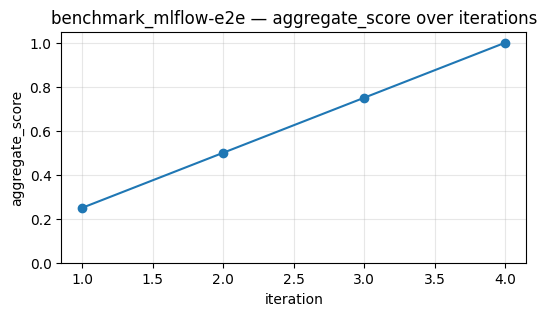

In [4]:
try:
    import matplotlib.pyplot as plt

    ys = [r["aggregate_score"] for r in DEMO1_RUNS]
    plt.figure(figsize=(6, 3))
    plt.plot(range(1, len(ys) + 1), ys, marker="o")
    plt.title("benchmark_mlflow-e2e — aggregate_score over iterations")
    plt.xlabel("iteration")
    plt.ylabel("aggregate_score")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.show()
except ImportError:
    print("matplotlib 未安裝，略過畫圖（pip install matplotlib）")

## Demo 2 — Best-effort 降級（MLflow 掛掉不影響 benchmark）

停掉 MLflow → 跑一個 run → 仍 completed、只是 mlflow_run_id 為 null → 復原。
需要 notebook kernel 有 docker CLI 權限。

注意：這個 demo 刻意用 chat 當目標，**不是** lifecycle_infer。原因是受測模型
qwen3-0.6B 由 Module 07 提供，而 Module 07 用「我們正要停掉的那個 MLflow」當
模型 registry —— 停掉 MLflow 會連帶讓模型的 registry 查詢失敗，輸出變空、分數
歸零，混淆「只有 benchmark 的 run-history logging 掛掉」這個重點。chat 由
raptor-chat-service 提供、與這個 MLflow 無關，才能乾淨地只示範 best-effort。

In [5]:
SCHEMA_BESTEFFORT = create_schema({
    "name": "besteffort-demo", "version": "1.0", "target_pipeline": "chat",
    "test_cases": [{"id": "tc1", "input": {"message": "hello", "user_id": "bench"},
                    "expected_keywords": ["hello"]}],
    "scoring_schema": {"dimensions": [
        {"name": "keywords", "weight": 1.0, "method": "keyword_match"}]},
})

print("\n1) 停掉 MLflow")
docker("stop", MLFLOW_CONTAINER)

print("\n2) 重跑一個 run（仍有真實分數，只是 mlflow_run_id 為 null）")
rec = run_once(SCHEMA_BESTEFFORT)
assert rec["status"] == "completed", "run 應仍完成"
assert rec["mlflow_run_id"] is None, "MLflow 不可達時 mlflow_run_id 應為 null"
print("   ✓ run 仍 completed，mlflow_run_id 為 None（best-effort 生效）")

print("\n3) 服務 log 出現 warning（非 error）")
docker("logs", "benchmark-dev-service", "--tail", "30")

print("\n4) 復原 MLflow")
docker("start", MLFLOW_CONTAINER)
time.sleep(8)
print("health:", requests.get(f"{MLFLOW}/health", timeout=10).text)


schema created: besteffort-demo -> b50f7d3f-1a03-42ba-b0c2-0a3d946f8d5f

1) 停掉 MLflow
aiml-v314-mlflow

2) 重跑一個 run
  run 30ee0c80 -> completed (aggregate=1.0, mlflow_run_id=None)
   ✓ run 仍 completed，mlflow_run_id 為 None（best-effort 生效）

3) 服務 log 出現 warning（非 error）
🧪 View experiment at: http://aiml-v314-mlflow:5557/#/experiments/4
INFO:     192.168.32.1:51798 - "GET /api/v1/benchmark/runs/ecd70dcb-8088-469e-8c81-e0be51dcf591 HTTP/1.1" 200 OK
INFO:     192.168.32.1:51814 - "POST /api/v1/benchmark/schemas HTTP/1.1" 201 Created
INFO:     192.168.32.1:51818 - "POST /api/v1/benchmark/runs HTTP/1.1" 202 Accepted
INFO:     192.168.32.1:51824 - "GET /api/v1/benchmark/runs/b407eeb3-0386-49c6-b8e8-7112e9a140a7 HTTP/1.1" 200 OK
🏃 View run b407eeb3-0386-49c6-b8e8-7112e9a140a7 at: http://aiml-v314-mlflow:5557/#/experiments/4/runs/cda11b867d6048deb69c523d615b2a18
🧪 View experiment at: http://aiml-v314-mlflow:5557/#/experiments/4
INFO:     192.168.32.1:51838 - "GET /api/v1/benchmark/runs/b407eeb3-

## Demo 3 — LLM-as-Judge：主觀品質評分

schema 沒有關鍵字可比對，改由 LLM 依 rubric 打分（是否切題）。

In [6]:
SCHEMA_JUDGE = create_schema({
    "name": "llm-judge-demo",
    "version": "1.0",
    "target_pipeline": TARGET_PIPELINE,
    "test_cases": [
        {"id": "tc1", "input": {"inputs": "What is the capital of France?"}},
        {"id": "tc2", "input": {"inputs": "Explain photosynthesis in one sentence."}},
    ],
    "scoring_schema": {
        "dimensions": [
            {"name": "relevance", "weight": 1.0, "method": "llm_judge",
             "rubric": "Score 1-5: does the answer correctly and directly address the question?"},
        ],
        "score_range": [1, 5],
    },
    "judge_model": JUDGE_MODEL,   # 評審用 gemma3-12b，受測用 qwen3-0.6B
})

rec = run_once(SCHEMA_JUDGE, TARGET_CONFIG)

print("\n== 逐題結果（output 是 qwen3-0.6B 的回答，relevance 是 gemma3-12b 打的分）==")
for c in rec["scores_per_case"]:
    print(f"  {c['case_id']}: relevance={c['per_dimension'].get('relevance')}  "
          f"aggregate={c['aggregate']}  error={c['error']}")
    print(f"    output: {c['output'][:120]!r}")

print("\n== MLflow 端：LLM 評出的分數一樣進了趨勢圖 ==")
for run in mlflow_runs("benchmark_llm-judge-demo"):
    print(f"  {run['run_name'][:8]}  {run['metrics']}")

schema created: llm-judge-demo -> 623c1407-a628-444d-9d15-74855d200066
  run d4d89242 -> completed (aggregate=1.0, mlflow_run_id=None)

== 逐題結果（output 是 chat 真實回答，relevance 是 LLM 打的分）==
  tc1: relevance=1.0  aggregate=1.0  error=None
    output: 'The capital of France is Paris. Since your question did not involve searching specific content, documents, images, video'
  tc2: relevance=1.0  aggregate=1.0  error=None
    output: 'Photosynthesis is the process by which plants, algae, and some bacteria convert light energy into chemical energy stored'

== MLflow 端：LLM 評出的分數一樣進了趨勢圖 ==
  d4d89242  {}


## Demo 4 — Pairwise 頭對頭比較（LLM judge 的另一種用法）

不看絕對分數，直接問 LLM「哪個答案比較好」。compare 要求兩個 run 屬於**同一
schema**，所以這裡對同一份 judge schema 跑兩次再比。內部用 swap + agree 消除
位置偏差（同一對答案正反問兩次、一致才算贏）。

註：若兩次 run 的輸出相近，判 TIE 是**正確**結果。實務上這個功能是拿「baseline
vs 調校後模型」兩個輸出明顯不同的 run 來比，勝負才會明顯。

In [7]:
print("對 llm-judge-demo 跑兩次，取得同 schema 的兩個 run")
run_a = run_once(SCHEMA_JUDGE)["run_id"]
run_b = run_once(SCHEMA_JUDGE)["run_id"]

result = compare(run_a, run_b, pairwise=True)
print(f"\ncompare A={run_a[:8]} vs B={run_b[:8]}")
print("delta_aggregate:", result["delta_aggregate"])
print("dimensions:", [(d["name"], d["delta"]) for d in result["dimensions"]])
print("\npairwise 逐題勝負:")
for c in result["pairwise"]["cases"]:
    print(f"  {c['case_id']}: winner={c['winner']}")
pw = result["pairwise"]
print(f"\n  A wins={pw['a_wins']}  B wins={pw['b_wins']}  ties={pw['ties']}  "
      f"b_win_rate={pw['b_win_rate']}")


對 llm-judge-demo 跑兩次，取得同 schema 的兩個 run
  run 38058d4d -> completed (aggregate=1.0, mlflow_run_id=b209d209c53f4a55bbe50c4e2f78ea1d)
  run 811da9bf -> completed (aggregate=1.0, mlflow_run_id=978ee682ad04438494f2e2045fff5e75)

compare A=38058d4d vs B=811da9bf
delta_aggregate: 0.0
dimensions: [('relevance', 0.0)]

pairwise 逐題勝負:
  tc1: winner=A
  tc2: winner=TIE

  A wins=1  B wins=0  ties=1  b_win_rate=0.0
